# Exploring Aerosol–Cloud Interactions with MODIS Aqua


## Overview

Aerosols and clouds are coupled: aerosol particles can act as cloud condensation
nuclei, and the meteorological conditions that load the atmosphere with aerosol
also tend to favour (or suppress) cloud. The **MODIS Aqua monthly Level-3
atmosphere product** (`MYD08_M3`) puts aerosol and cloud retrievals on the same
1°×1° grid, which makes it a convenient starting point for inspecting that
coupling.

In this notebook we will:

1. Open a monthly `MYD08_M3` granule stored as **HDF4**.
2. Read three fields — aerosol optical depth, cloud fraction, and liquid cloud
   optical thickness — and apply the fill-value / scale / offset encoding.
3. Map them on a global PlateCarree grid.
4. Bin cloud fraction by aerosol optical depth to inspect the
   aerosol–cloud signal, and discuss why the result is suggestive rather than
   causal.

## Prerequisites

| Concepts | Importance | Notes |
| --- | --- | --- |
| [Intro to Xarray](https://foundations.projectpythia.org/core/xarray.html) | Helpful | We work mostly with NumPy arrays here |
| HDF4 / `pyhdf` | Necessary | MODIS L3 ships as HDF4, read with `pyhdf.SD` |
| Scale/offset metadata | Necessary | Packed integers must be decoded to physical units |
| [Cartopy](https://foundations.projectpythia.org/core/cartopy.html) | Helpful | Global maps with coastlines |

**The data:** one `MYD08_M3` granule for January 2014
(`MYD08_M3.A2014001.061.2018052053238.hdf`). 

## The data product

`MYD08_M3` bundles dozens of aggregated statistics. We keep three:

| Dataset name | What it is |
| --- | --- |
| `AOD_550_Dark_Target_Deep_Blue_Combined_Mean_Mean` | Aerosol optical depth at 550 nm (combined land+ocean retrieval) |
| `Cloud_Fraction_Mean_Mean` | Fraction of the grid cell flagged cloudy |
| `Cloud_Optical_Thickness_Liquid_Mean_Mean` | Optical thickness of liquid-phase clouds |


# Imports

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from pyhdf.SD import SD, SDC

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 6)

## The data

Our file is a single MODIS Aqua Level-3 granule holding global monthly-mean
atmosphere statistics for January 2014. It contains dozens of variables; we'll
pull just three.

In [2]:

plt.rcParams["font.family"] = "DejaVu Sans"

hdf_path = "MODIS_Jan2014/MYD08_M3.A2014001.061.2018052053238.hdf"

plot_cfg = {
    "AOD_550_Dark_Target_Deep_Blue_Combined_Mean_Mean": {
        "title": "Aerosol optical depth at 550 nm (Dark Target / Deep Blue combined)",
        "label": "AOD (unitless)",
        "cmap": "YlOrRd", "vmin": 0.0, "vmax": 1.0,},
    
    "Cloud_Fraction_Mean_Mean": {
        "title": "Cloud fraction",
        "label": "Fraction",
        "cmap": "GnBu", "vmin": 0.0, "vmax": 1.0,},
    
    "Cloud_Optical_Thickness_Liquid_Mean_Mean": {
        "title": "Liquid cloud optical thickness",
        "label": "COT (unitless)",
        "cmap": "viridis", "vmin": 0.0, "vmax": 40.0,},}

# Read from the HDF

In [3]:
hdf = SD(hdf_path, SDC.READ)
fields = {}
for var_name in plot_cfg:
    var = hdf.select(var_name)
    data = var[:].astype(float)
    attrs = var.attributes()
    data = np.where(data == attrs.get("_FillValue", -9999), np.nan, data)
    data = data * attrs.get("scale_factor", 1.0) + attrs.get("add_offset", 0.0)
    fields[var_name] = data

ny, nx = next(iter(fields.values())).shape
lat = np.linspace(89.5, -89.5, ny)
lon = np.linspace(-179.5, 179.5, nx)

# Plot

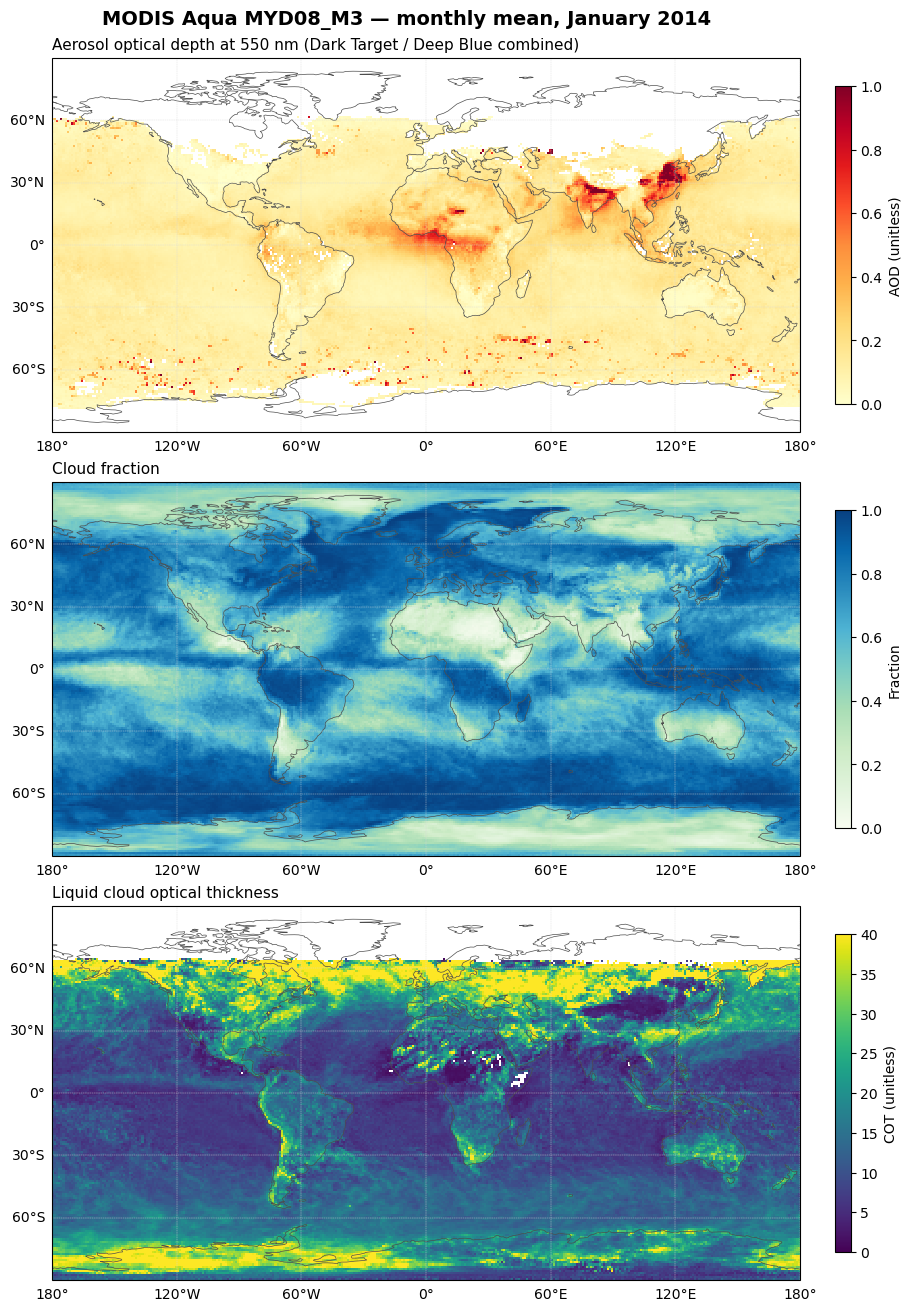

In [4]:
proj = ccrs.PlateCarree()
fig, axes = plt.subplots(
    nrows=len(plot_cfg), ncols=1,
    figsize=(10, 13),
    subplot_kw={"projection": proj},
    constrained_layout=True,)

for ax, (var_name, cfg) in zip(axes, plot_cfg.items()):
    mesh = ax.pcolormesh(
        lon, lat, fields[var_name],
        transform=proj, cmap=cfg["cmap"],
        vmin=cfg["vmin"], vmax=cfg["vmax"], shading="auto",)
    
    ax.coastlines(linewidth=0.5, color="0.3")
    ax.set_global()

    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="0.85", linestyle="--")
    gl.top_labels = False
    gl.right_labels = False

    cbar = fig.colorbar(mesh, ax=ax, orientation="vertical", shrink=0.85, pad=0.02)
    cbar.set_label(cfg["label"])

    ax.set_title(cfg["title"], loc="left", fontsize=11)

fig.suptitle("MODIS Aqua MYD08_M3 — monthly mean, January 2014",
    fontsize=14, fontweight="bold",)

fig.savefig(
    "MYD08_M3_Jan2014_maps.png",
    dpi=300, facecolor="white", bbox_inches="tight",)
plt.show()

## Resources and references

- [MODIS Atmosphere L3 product (MYD08) documentation](https://modis-atmosphere.gsfc.nasa.gov/products/monthly)

- Notebook structure adapted from the *Project Pythia CMIP6 Cookbook*